## Coursework: TD3 DDPG
Extending from the lab (DDPG) and applying the TD3 improvement solution provided by OpenAI.

Repository reference: https://github.com/sfujim/TD3

TD3 reference: https://spinningup.openai.com/en/latest/algorithms/td3.html

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install swig

In [ ]:
!pip install "gymnasium[box2d]"

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"using {device} backend")

using cpu backend


In [ ]:

# --- Networks ---
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, action_dim),
            nn.Tanh() # Continuous actions are usually bounded [-1, 1]
        )
        self.max_action = max_action

    def forward(self, x):
        return self.max_action * self.net(x)

# For TD3, the Critic class now has two Q networks
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        # Q1 architecture
        self.q1 = nn.Sequential(
            nn.Linear(state_dim + action_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1)
        )
        # Q2 architecture
        self.q2 = nn.Sequential(
            nn.Linear(state_dim + action_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, state, action):
        q1 = self.q1(torch.cat([state, action], 1))
        q2 = self.q2(torch.cat([state, action], 1))
        return q1, q2

    # Following TD3 implementation
    def Q1(self, state, action):
      q1 = self.q1(torch.cat([state, action], 1))
      return q1

# --- Replay Buffer ---
class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return (torch.FloatTensor(np.array(state)).to(device),
                torch.FloatTensor(np.array(action)).to(device),
                torch.FloatTensor(np.array(reward)).unsqueeze(1).to(device),
                torch.FloatTensor(np.array(next_state)).to(device),
                torch.FloatTensor(np.array(done)).unsqueeze(1).to(device))

## Training

In [ ]:
def train_ddpg(episodes=900, batch_size=128, tau=0.005, gamma=0.99):
    env = gym.make("LunarLander-v3", continuous=True)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    max_action = float(env.action_space.high[0])

    actor = Actor(state_dim, action_dim, max_action).to(device)
    actor_target = Actor(state_dim, action_dim, max_action).to(device)
    actor_target.load_state_dict(actor.state_dict())
    actor_opt = optim.Adam(actor.parameters(), lr=1e-4)

    critic = Critic(state_dim, action_dim).to(device)
    critic_target = Critic(state_dim, action_dim).to(device)
    critic_target.load_state_dict(critic.state_dict())
    critic_opt = optim.Adam(critic.parameters(), lr=1e-3)

    replay_buffer = ReplayBuffer()

    policy_noise = 0.2
    policy_freq=2

    rewards_history, actor_losses_history, critic_losses_history = [], [], []

    for ep in range(episodes):
        state, _ = env.reset()
        episode_reward = 0
        actor_ep_losses, critic_ep_losses = [], []
        delay = 0 # For TD3 delay

        for t in range(500):
            # Selection with exploration noise
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            action = actor(state_t).detach().cpu().numpy()[0]
            action = (action + np.random.normal(0, 0.1, size=action_dim)).clip(-max_action, max_action)

            next_state, reward, term, trunc, _ = env.step(action)
            done = term or trunc
            replay_buffer.push(state, action, reward, next_state, done)

            state = next_state
            episode_reward += reward

            # Update
            if len(replay_buffer.buffer) > batch_size:
                delay += 1
                b_s, b_a, b_r, b_ns, b_d = replay_buffer.sample(batch_size)

                # Critic Update
                with torch.no_grad():
                    action = torch.from_numpy(action).float()
                    noise = (torch.randn_like(action) * policy_noise)
                    next_action = (actor_target(b_ns) + noise).clamp(-max_action, max_action)
                    # TD3 utilises 2 Q networks
                    target_Q1, target_Q2 = critic_target(b_ns, next_action)
                    target_Q = torch.min(target_Q1, target_Q2)
                    target_Q = b_r + (gamma * (1 - b_d) * target_Q)


                current_Q1, current_Q2 = critic(b_s, b_a)
                # Both Q networks are used for the loss
                critic_loss = nn.MSELoss()(current_Q1, target_Q) + nn.MSELoss()(current_Q2, target_Q)

                critic_opt.zero_grad()
                critic_loss.backward()
                critic_opt.step()
                critic_ep_losses.append(critic_loss.item())

                # TD3 delay for Actor loss
                if delay % policy_freq == 0:
                  actor_loss = -critic.Q1(b_s, actor(b_s)).mean()
                  actor_opt.zero_grad()
                  actor_loss.backward()
                  actor_opt.step()
                  actor_ep_losses.append(actor_loss.item())


                # Soft updates
                for param, target_param in zip(actor.parameters(), actor_target.parameters()):
                    target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)
                for param, target_param in zip(critic.parameters(), critic_target.parameters()):
                    target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)

            if done: break

        print(f"Episode {ep} | Reward: {episode_reward:.2f}")

        rewards_history.append(episode_reward)

        # Track actor and critic losses separately
        if actor_ep_losses:
            actor_losses_history.append(np.mean(actor_ep_losses))

        if critic_ep_losses:
            critic_losses_history.append(np.mean(critic_ep_losses))

    plot_graphs(rewards_history, actor_losses_history, critic_losses_history)

    return actor

In [ ]:
def plot_graphs(rewards, actor_losses, critic_losses):
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

    # Save graph arrays for later loading
    rewards_path = '/content/drive/MyDrive/RL_CW/td3/E1_td3_rewards.npy'
    ac_losses_path = '/content/drive/MyDrive/RL_CW/td3/E1_td3_losses.npy'
    cr_losses_path = '/content/drive/MyDrive/RL_CW/graphs/E1_td3_priorities.npy'

    # Save the numpy arrays
    np.save(rewards_path, np.array(rewards))
    np.save(ac_losses_path, np.array(actor_losses))
    np.save(cr_losses_path, np.array(critic_losses))

    #print(ep_priorities)

    # Success Rate (Moving Average)
    window = 50
    #print("rewards", rewards)
    mov_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
    ax1.plot(mov_avg, color='blue')
    ax1.set_title(f"Success Rate ({window} Episode Moving Average)")
    ax1.set_xlabel("Episode"); ax1.set_ylabel("Reward")

    # Actor Loss
    ax2.plot(actor_losses, alpha=0.5)
    ax2.set_title("Training Actor Loss")
    ax2.set_xlabel("Episode"); ax2.set_ylabel("Loss")

    # Critic Loss
    ax3.plot(critic_losses, alpha=0.5)
    ax3.set_title("Training Critic Loss")
    ax3.set_xlabel("Episode"); ax3.set_ylabel("Loss")

    plt.tight_layout()
    plt.show()

In [ ]:
import imageio

def save_lander_gif(actor, filename="lunar_lander_td3.gif"):
    env = gym.make("LunarLander-v3", continuous=True, render_mode="rgb_array")
    state, _ = env.reset()
    frames, done = [], False

    while not done:
        frames.append(env.render())
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad(): # No training
            action = actor(state_t).cpu().numpy()[0]
        state, _, term, trunc, _ = env.step(action)
        done = term or trunc

    imageio.mimsave(filename, frames, fps=30, loop=0)
    env.close()
    print(f"Visualized lander saved to {filename}")

Episode 0 | Reward: -263.32
Episode 1 | Reward: -119.84
Episode 2 | Reward: -111.97
Episode 3 | Reward: -517.80
Episode 4 | Reward: -1031.16
Episode 5 | Reward: -604.24
Episode 6 | Reward: -341.97
Episode 7 | Reward: -44.29
Episode 8 | Reward: -110.19
Episode 9 | Reward: -371.45
Episode 10 | Reward: -738.82
Episode 11 | Reward: -269.12
Episode 12 | Reward: -239.78
Episode 13 | Reward: -406.69
Episode 14 | Reward: -500.45
Episode 15 | Reward: -64.33
Episode 16 | Reward: -331.21
Episode 17 | Reward: -421.93
Episode 18 | Reward: -444.44
Episode 19 | Reward: -269.43
Episode 20 | Reward: -352.08
Episode 21 | Reward: -285.31
Episode 22 | Reward: -382.83
Episode 23 | Reward: -246.57
Episode 24 | Reward: -274.03
Episode 25 | Reward: -279.05
Episode 26 | Reward: -161.52
Episode 27 | Reward: -129.27
Episode 28 | Reward: -212.27
Episode 29 | Reward: -224.59
Episode 30 | Reward: -316.74
Episode 31 | Reward: -235.70
Episode 32 | Reward: -300.50
Episode 33 | Reward: -175.65
Episode 34 | Reward: -193

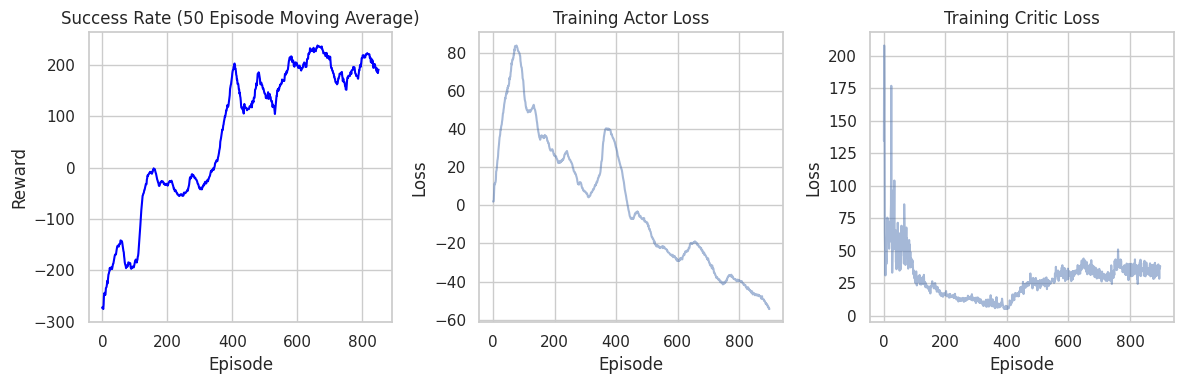

Training completed


In [ ]:

actor_model = train_ddpg()
print("Training completed")

In [ ]:
save_lander_gif(actor_model, "lunar_lander_td3.gif")

Visualized lander saved to lunar_lander_td3.gif


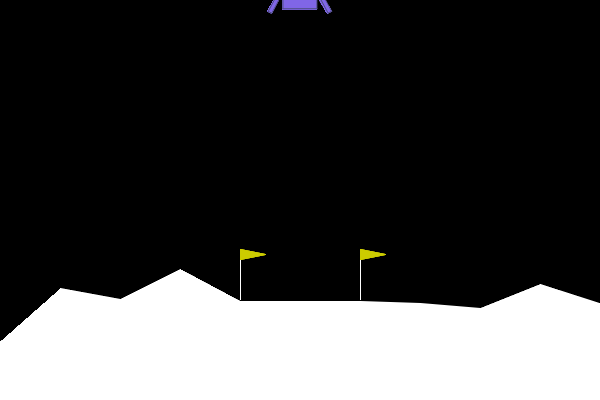

In [ ]:
from IPython.display import Image
Image(filename="lunar_lander_td3.gif")

In [ ]:
from google.colab import files
files.download("lunar_lander_td3.gif")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>